In [ ]:
import networkx as nx
from torch_geometric import utils
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from torch_geometric import utils 
import json
import scipy.io as sio

from trainer import Trainer
from datasets.import_dataset import import_dataset, load_data_matlab_format
from utils.plotting import *
import utils.link_prediction as lp
from datasets.simulations import create_sbm
from utils import pyg_helpers as up
from utils.plotting import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
ds = import_dataset('squirrel')
#todo: load 10 test sets and run on the server. every split should be marked by the binary number that is given by the test mask. inside, every validation folder should have acc configs files.

# need to build a saving mechanism to the test and val sets and name the split after the test set

In [77]:
import os
import shutil

parent_folder = 'experiments/results/link_prediction/ogb_hAk/ogbl-ddi/pieclam/split0/valid'

for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    if os.path.isdir(subfolder_path):
        # Move each file to the parent folder
        for filename in os.listdir(subfolder_path):
            file_path = os.path.join(subfolder_path, filename)
            if os.path.isfile(file_path):
                shutil.move(file_path, os.path.join(parent_folder, filename))
        
        # After moving files, delete the now-empty subfolder
        os.rmdir(subfolder_path)

print('Done!')

#todo: make the print folder function be right.
#todo: make the simulation in slurm run with the default parameters if all of the products are an empty set

Done!


In [68]:

# change hypers.py to ../hypers.py

import os

parent_folder = 'experiments/scripts/link_prediction/hypers_search'

for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    if os.path.isdir(subfolder_path):
        for file in os.listdir(subfolder_path):
            if file.endswith('.sbatch'):
                file_path = os.path.join(subfolder_path, file)

                # Read file
                with open(file_path, 'r') as f:
                    lines = f.readlines()

                # Replace hypers_search.py with ../hypers_search.py
                new_lines = [line.replace('python -u hypers_search.py', 'python -u ../hypers_search.py')
                             for line in lines]

                # Write back
                with open(file_path, 'w') as f:
                    f.writelines(new_lines)

                print(f'Updated {file_path}')

Updated experiments/scripts/link_prediction/hypers_search/hopkins/pclam_hopkins.sbatch
Updated experiments/scripts/link_prediction/hypers_search/hopkins/bigclam_hopkins.sbatch
Updated experiments/scripts/link_prediction/hypers_search/hopkins/pieclam_hopkins.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/ieclam_texas_test.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pieclam_texas3.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pieclam_texas_test.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/ieclam_texas.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pieclam_texas4.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pieclam_texas.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pclam_texas.sbatch
Updated experiments/scripts/link_prediction/hypers_search/texas/pieclam_texas2.sbatch
Updated experiments/scripts/link_prediction/hy

In [46]:
path = 'datasets/Disenlink/texas_split_0.6_0.2_0.npz'
splits = np.load(path)

In [48]:
print(splits)

train_mask
val_mask
test_mask
[1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0
 1 0 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1
 1 1 1 1 1 0 0 0 0 1 0 1 1 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 0 1
 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 0 1 1 1 0
 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1]
[0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1
 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0
 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0
 

In [45]:
ds = import_dataset('squirrel')

KeyboardInterrupt: 

# compare disenlink data with downloaded

same, just need to undirect, remove isolates and self loops

In [25]:
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
# Suppose you have two PyG graphs: data1 and data2
def check_isomorphism(data1, data2):

    if (data1.edge_index == data2.edge_index).all():
        print("Graphs are identical")
        return True
    else:
        print("checking isomorphism")
        G1 = to_networkx(Data(edge_index=data1.edge_index))
        G2 = to_networkx(Data(edge_index=data2.edge_index))

        # Now use NetworkX's isomorphism check
        from networkx.algorithms import isomorphism

        GM = isomorphism.GraphMatcher(G1, G2)
        return GM.is_isomorphic()

In [42]:
# Convert edge indices to sets of tuples for comparison
orig = import_dataset('squirrel')

disen_path = 'datasets/Disenlink/squirrel.pt'
disen = torch.load(disen_path)[0]
disen.edge_index = utils.remove_self_loops(disen.edge_index)[0]
disen.edge_index, disen.edge_attr, mask = utils.remove_isolated_nodes(disen.edge_index)
disen.edge_index = utils.to_undirected(disen.edge_index)


print(check_isomorphism(orig, disen))
# edges_sq_orig = set(map(tuple, orig.edge_index.t().tolist()))
# edges_data = set(map(tuple, utils.to_undirected(disen.edge_index).t().tolist()))

# # Check if they are disjoint or if one is contained in the other
# if edges_sq_orig.issubset(edges_data):
#     print("The first edge index array is fully contained in the second set of edges.")
# elif edges_sq_orig.isdisjoint(edges_data):
#     print("The two edge index arrays are disjoint.")
# else:
#     print("The two edge index arrays have some overlap but are not fully contained.")

#   
# todo: in the disen dataset there are less edges in squirrel and texas

# todo: ok doesn't matter. just sample 10 test sets randomally
#todo: do not change anything, just sample train sets

Graphs are identical
True


In [11]:
a = disen

AttributeError: 'GlobalStorage' object has no attribute 'remove_isolated_nodes'

/Users/danielzilberg/anaconda3/envs/pyg/lib/python3.10/site-packages/torch_geometric/data/storage.py:450: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


False


In [52]:
# TURN THE ACC_CONFIG FILES INTO FOLDERS WITH THE SPLIT AND ACC_CONFIG RESULTS

import os
import shutil

folder = 'experiments/results/link_prediction/auc/JohnsHopkins55/pclam/split0/test'

for filename in os.listdir(folder):
    if filename.startswith("acc_configs_"):
        suffix = filename[len("acc_configs_"):].split(".")[0]
        target_dir = os.path.join(folder, suffix)
        os.makedirs(target_dir, exist_ok=True)
        src_path = os.path.join(folder, filename)
        dst_path = os.path.join(target_dir, filename)
        shutil.move(src_path, dst_path)

In [28]:
orig

Data(edge_index=[2, 396706], y=[5201], edge_attr=[396706], num_nodes=5201, gt_nomalous=[5201], name='squirrel')

In [14]:
orig

Data(edge_index=[2, 396706], y=[5201], edge_attr=[396706], num_nodes=5201, gt_nomalous=[5201], name='squirrel')

In [24]:
a = torch.tensor([[2,1,4],[5,2,6]])
utils.to_undirected(a)


tensor([[1, 2, 2, 4, 5, 6],
        [2, 1, 5, 6, 2, 4]])

In [20]:
ds = import_dataset('ogbl-ddi')

omitted edges tensor([[2, 5],
        [5, 2]])
omitted non edges tensor([[0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 5],
        [1, 2, 3, 0, 2, 3, 4, 0, 1, 4, 0, 1, 4, 5, 1, 2, 3, 3]])
new_edge_index tensor([[0, 0, 1, 2, 4, 4, 5, 5, 3, 5, 2, 5, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3,
         3, 3, 4, 4, 4, 5],
        [4, 5, 5, 3, 5, 0, 0, 1, 2, 4, 5, 2, 1, 2, 3, 0, 2, 3, 4, 0, 1, 4, 0, 1,
         4, 5, 1, 2, 3, 3]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])


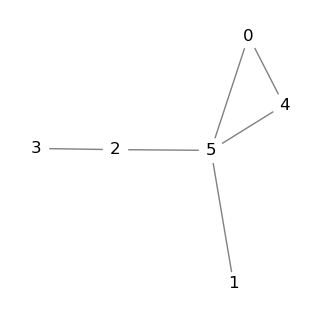

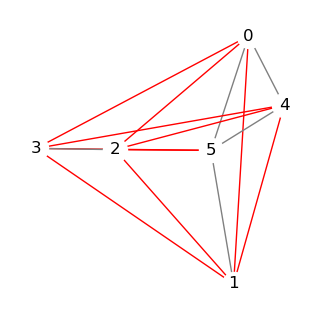

omitted edges (tensor([[0, 0, 1, 4, 5, 5],
        [4, 5, 5, 0, 0, 1]]), tensor([], size=(2, 0), dtype=torch.int64))
omitted non edges tensor([[2, 4, 3, 5, 0, 0, 1, 4, 5, 5, 2, 5, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3,
         3, 3, 4, 4, 4, 5],
        [3, 5, 2, 4, 4, 5, 5, 0, 0, 1, 5, 2, 1, 2, 3, 0, 2, 3, 4, 0, 1, 4, 0, 1,
         4, 5, 1, 2, 3, 3]])
new_edge_index tensor([[2, 4, 3, 5, 0, 0, 1, 4, 5, 5, 2, 5, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3,
         3, 3, 4, 4, 4, 5],
        [3, 5, 2, 4, 4, 5, 5, 0, 0, 1, 5, 2, 1, 2, 3, 0, 2, 3, 4, 0, 1, 4, 0, 1,
         4, 5, 1, 2, 3, 3]])
new_edge_attr tensor([ True,  True,  True,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])


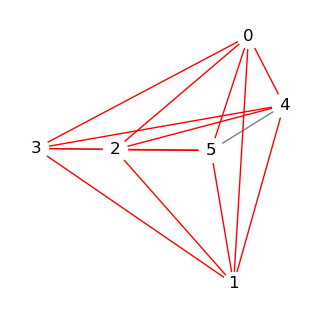

In [30]:
import networkx as nx
import matplotlib.pyplot as plt


data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 5, 5],
                                     [5, 4, 5, 2, 2, 4]]))

data.edge_attr = torch.tensor([1, 1, 1, 1, 1, 1]).bool()

data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
dyads_to_omit_test = lp.get_dyads_to_omit(data.edge_index, data.edge_attr, p_sample_edge=0.3)
data_omitted1 = Data(edge_index=dyads_to_omit_test[1], edge_attr=dyads_to_omit_test[2])

print('omitted edges', dyads_to_omit_test[0][0])
print('omitted non edges', dyads_to_omit_test[0][1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.get_dyads_to_omit(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.3)
data_omitted2 = Data(edge_index=dyads_to_omit_val[1], edge_attr=dyads_to_omit_val[2])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST






omitted edges tensor([[1, 2, 3, 5],
        [5, 3, 2, 1]])
omitted non edges tensor([[0, 1, 2, 3],
        [2, 3, 0, 1]])
new_edge_index tensor([[4, 0, 5, 4, 5, 0, 2, 5, 1, 2, 3, 5, 0, 1, 2, 3],
        [0, 4, 4, 5, 0, 5, 5, 2, 5, 3, 2, 1, 2, 3, 0, 1]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True,  True,  True, False, False,
        False, False, False, False, False, False])


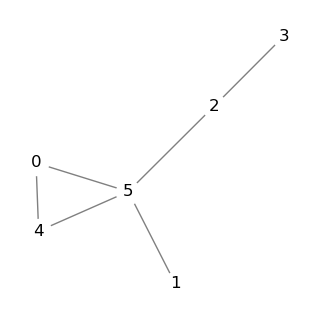

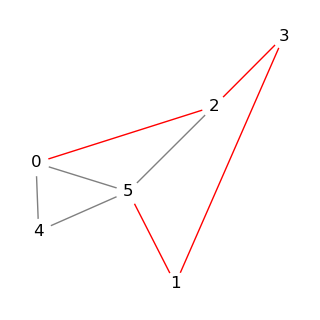

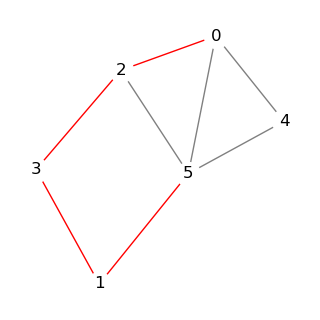

omitted edges (tensor([[0, 5],
        [5, 0]]), tensor([[0, 0, 1, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5],
        [1, 3, 0, 2, 4, 1, 4, 0, 4, 5, 1, 2, 3, 3]]))
omitted non edges tensor([[0, 4, 2, 4, 5, 5, 0, 5, 0, 0, 1, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 1, 2,
         3, 5, 0, 1, 2, 3],
        [4, 5, 5, 0, 4, 2, 5, 0, 1, 3, 0, 2, 4, 1, 4, 0, 4, 5, 1, 2, 3, 3, 5, 3,
         2, 1, 2, 3, 0, 1]])
new_edge_index tensor([[0, 4, 2, 4, 5, 5, 0, 5, 0, 0, 1, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 1, 2,
         3, 5, 0, 1, 2, 3],
        [4, 5, 5, 0, 4, 2, 5, 0, 1, 3, 0, 2, 4, 1, 4, 0, 4, 5, 1, 2, 3, 3, 5, 3,
         2, 1, 2, 3, 0, 1]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])


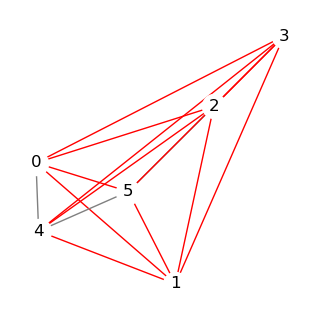

In [36]:
#TEST omit dyads function

import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected


data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 5, 5],
                                     [5, 4, 5, 2, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1]).bool()

data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

edges_to_omit = to_undirected(torch.tensor([[1, 3],
                              [5, 2]]))

non_edges_to_omit = to_undirected(torch.tensor([[3, 0],
                                  [1, 2]]))

dyad_tuple = (edges_to_omit, non_edges_to_omit)
#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)

dyads_to_omit_test = lp.omit_dyads(data.edge_index, data.edge_attr, dyad_tuple)
data_omitted1 = Data(edge_index=dyads_to_omit_test[1], edge_attr=dyads_to_omit_test[2])

print('omitted edges', dyads_to_omit_test[0][0])
print('omitted non edges', dyads_to_omit_test[0][1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.get_dyads_to_omit(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.3)
# Update the node labels to be white
plot_graph_with_omitted(data_omitted1)
data_omitted2 = Data(edge_index=dyads_to_omit_val[1], edge_attr=dyads_to_omit_val[2])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


In [40]:

# data1 = Data(edge_index=torch.tensor([[0, 1, 2, 0],
#                                      [1, 2, 3, 2]]))

# data1.edge_attr = torch.tensor([0,0,1,0])

# hopped1 = up.my_two_hop(data1)

# print(hopped1.edge_index)
# print(hopped1.edge_attr)

# print("")



data2.edge_attr = torch.tensor([1,1,1,1,0, 0]).bool()

data2 = Data(edge_index=torch.tensor([[0, 0, 1, 3, 5, 5],
                                     [5, 4, 5, 2, 2, 4]]))

data2.edge_index, data2.edge_attr = utils.to_undirected(data2.edge_index, data2.edge_attr)

edge_index, edge_attr = up.my_two_hop(data2)

print(edge_index)
print(edge_attr)

/home/user/anaconda3/envs/piegam/lib/python3.11/site-packages/torch_geometric/data/storage.py:450: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


tensor([[0, 0, 0, 1, 1, 2, 2, 3, 4, 4, 5, 5, 5, 5],
        [1, 4, 5, 0, 5, 3, 5, 2, 0, 5, 0, 1, 2, 4]])
tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True,
         True,  True, False,  True])


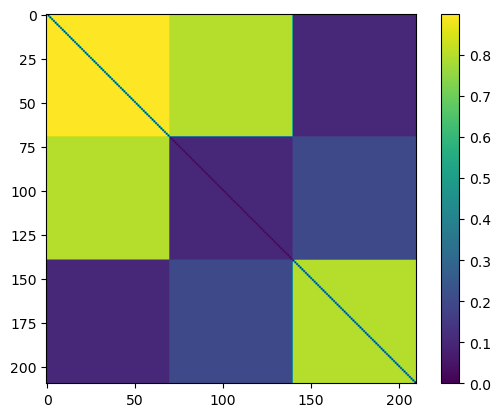

In [519]:
prob_adj_3X3, y = create_sbm(70, p_comm=[0.9, 0.1, 0.8], p_bipart=[0.8, 0.1, 0.2])

plt.imshow(prob_adj_3X3)
plt.colorbar()

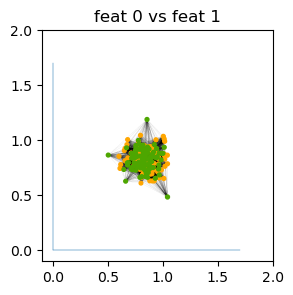

In [516]:
trainer_bigclam_bipart.plot_state(things_to_plot=['2dgraphs'])

In [494]:
data_bipart = import_dataset('bipartite')
config_triplets=[

['clamiter_init', 'dim_feat', 2],
['feat_opt', 'n_iter', 1000]
]
trainer_bigclam_bipart = Trainer(dataset=data_bipart, 
                                 model_name='bigclam',
                                 device='cpu',
                                 config_triplets_to_change=config_triplets,
                                )

trainer_bigclam_bipart.train()


#todo: change trainer to not havbe the option of model name, and that dataset will not have a default value and test it

TypeError: Trainer.__init__() got an unexpected keyword argument 'plot_every'

# karate

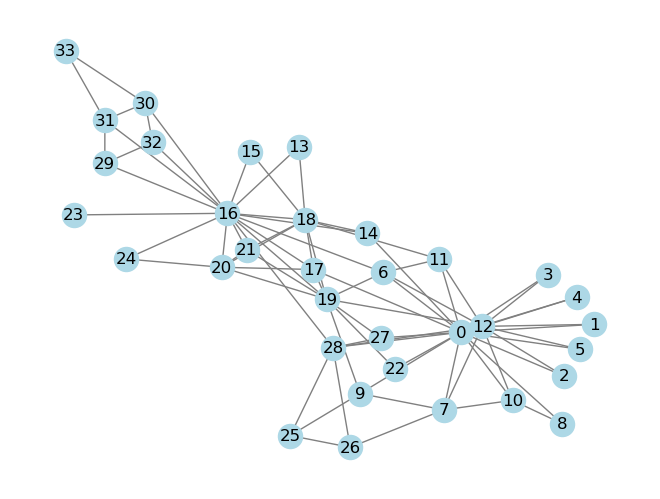

In [483]:
data_karate = import_dataset('karate')
data_karate_nx = nx.Graph()
data_karate_nx.add_edges_from(data_karate.edge_index.t().tolist())
nx.draw(data_karate_nx, with_labels=True, node_color='lightblue', edge_color='gray')
karate_adj = utils.to_dense_adj(data_karate.edge_index)[0]

plt.show()

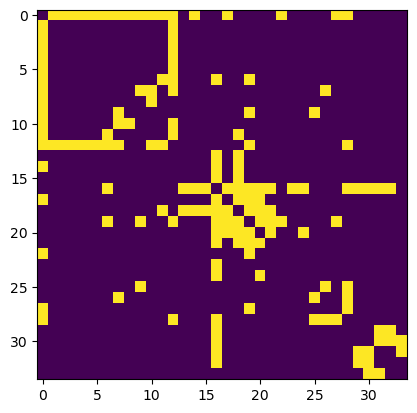

In [485]:
plt.imshow(karate_adj)



/home/user/Documents/danny/AAAI_pieclam/trainer.py:301:::  
 starting optimization of bigclam on karate on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 2,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 20000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/clamiter.py:368:::  
fit wrapper fit_feats, plotting state at iter 19999


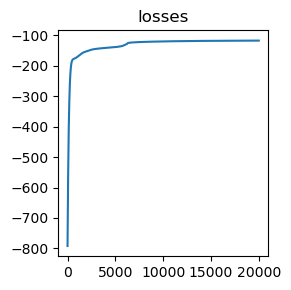

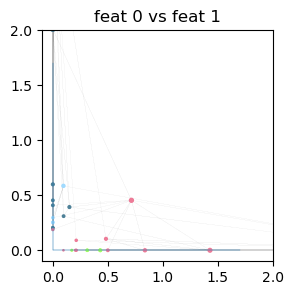

In [472]:

config_triplets = [
    ['clamiter_init', 'dim_feat', 2],
    ['feat_opt', 'lr', 0.0001],
    ['clamiter_init', 'l1_reg', 2]
]
trainer_karate_bigclam = Trainer(dataset=data_karate, 
                                 model_name='bigclam',
                                 task=None,
                                 config_triplets_to_change=config_triplets,
                                 device='cpu')

losses, _, _ = trainer_karate_bigclam.train()

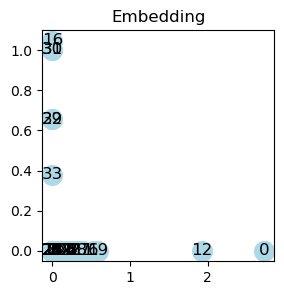

In [458]:
embedding1 = {node:trainer_karate_bigclam.data.x[node]  for node in data_karate_nx.nodes}
# embedding2 = {node: np.random.rand(2) for node in G.nodes}
# Plot the first embedding
plt.figure(figsize=(3, 3))
for node, emb in embedding1.items():
    plt.scatter(emb[0], emb[1], s=200, c='lightblue')
    plt.text(emb[0], emb[1], s=str(node), horizontalalignment='center', verticalalignment='center', color='black', fontsize=12)  # Change the color to black

plt.title('Embedding')
plt.show()


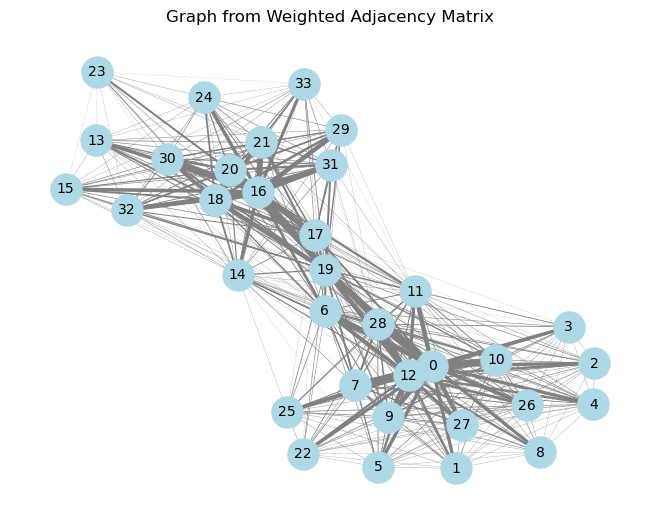

In [484]:

weighted_adj_matrix = trainer_karate_bigclam.get_prob_graph().numpy()


import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Example weighted adjacency matrix

G = nx.from_numpy_array(weighted_adj_matrix)

# Define edge weights for drawing
edge_weights = nx.get_edge_attributes(G, 'weight')

# Normalize the edge weights for better visualization (optional)
max_weight = max(edge_weights.values())
normalized_weights = [weight / max_weight * 5 for weight in edge_weights.values()]

# Plot the graph
pos = nx.spring_layout(G)  # You can choose different layouts
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, 
        width=normalized_weights, edge_color='gray')

plt.title('Graph from Weighted Adjacency Matrix')
plt.show()

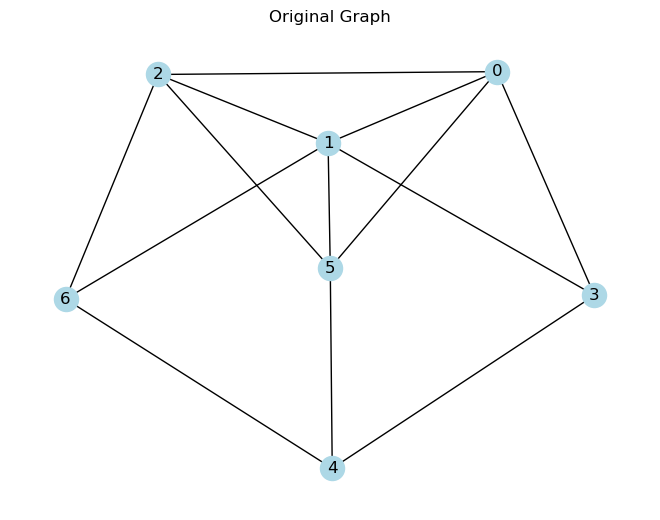

In [82]:

# Create an empty graph
# Draw the graph
# Generate an Erdos-Reyni graph with 6 nodes
ER_graph = nx.erdos_renyi_graph(7, 0.5)
data = utils.from_networkx(ER_graph)
data.name = 'graph'
# Draw the graph
nx.draw(ER_graph, with_labels=True, node_color='lightblue')
plt.title('Original Graph')
plt.show()



/home/user/Documents/danny/AAAI_pieclam/trainer.py:301:::  
 starting optimization of bigclam on graph on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 100000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/clamiter.py:368:::  
fit wrapper fit_feats, plotting state at iter 99999


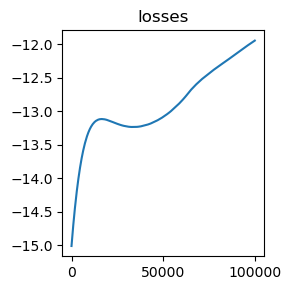

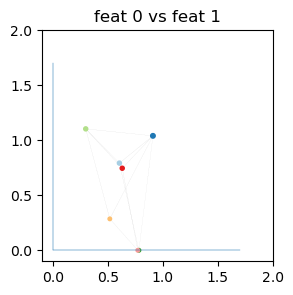

In [432]:
config_triplets = [
    ['clamiter_init', 'dim_feat', 2],
    ['feat_opt', 'n_iter', 100000],
    ['feat_opt', 'lr', 1e-5]
]

trainer_iegam = Trainer(dataset=data.clone(),
                        model_name='bigclam',
                        task=None,
                        device='cpu',
                        config_triplets_to_change=config_triplets)

losses, acc_test, acc_val = trainer_iegam.train()
# trainer_iegam.plot_state()

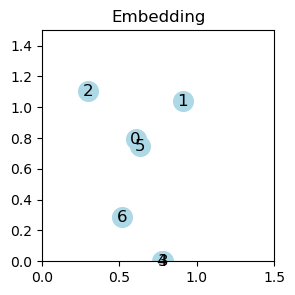

In [435]:
embedding1 = {node:trainer_iegam.data.x[node]  for node in ER_graph.nodes}
# embedding2 = {node: np.random.rand(2) for node in G.nodes}
# Plot the first embedding
plt.figure(figsize=(3, 3))
for node, emb in embedding1.items():
    plt.scatter(emb[0], emb[1], s=200, c='lightblue')
    plt.text(emb[0], emb[1], s=str(node), horizontalalignment='center', verticalalignment='center', color='black', fontsize=12)  # Change the color to black

plt.title('Embedding')
plt.show()


In [350]:

weighted_adj_matrix = trainer_iegam.get_prob_graph().numpy()


import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Example weighted adjacency matrix

G = nx.from_numpy_array(weighted_adj_matrix)

# Define edge weights for drawing
edge_weights = nx.get_edge_attributes(G, 'weight')

# Normalize the edge weights for better visualization (optional)
max_weight = max(edge_weights.values())
normalized_weights = [weight / max_weight * 5 for weight in edge_weights.values()]

# Plot the graph
pos = nx.spring_layout(G)  # You can choose different layouts
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, 
        width=normalized_weights, edge_color='gray')

plt.title('Graph from Weighted Adjacency Matrix')
plt.show()